### **Data**

[Transactions Data Bank ⛔||⛔ Fraud Detection](https://www.kaggle.com/datasets/qusaybtoush1990/transactions-data-bank-fraud-detection?resource=download)

### **Импорт библиотек**

In [1]:
from pathlib import Path
Path.cwd()


PosixPath('/content')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown, HTML
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import optuna

### **Загрузка данных**

In [5]:
url = f'/content/drive/MyDrive/HSE/Year_project/Fraud.csv'
df = pd.read_csv(url)

### **Описание датасета**

|Сolumn  | Description |
|------------|-------------|
|Date | Date of Transaction|
|nameOrig | User Name or Account number|
|amount | Money in this transaction|
|oldbalanceOrg | How much the client had money before transaction|
|newbalanceOrig | How much the client have after the transaction|
|City |where the transaction happened which city|
|type | Type of transaction TRANSFER \ CASH_OUT, CASH_IN ,DEBIT,PAYMENT|
|Card Type | The card type the client has \ Platinum ,Gold ,Silver ,Signature ,Classic ,Mass|
|Exp Type | The purpose for transaction \ Food, Entertainment, Fuel, Bills, Grocery, Travel, Personal_Care, Health_Fitness, Home|
|Gender |Male or Female|
|isFraud | 0 = no fraud, 1 = fraud|


In [ ]:
df.head()

,Date,nameOrig,amount,oldbalanceOrg,newbalanceOrig,City,type,Card Type,Exp Type,Gender,isFraud
0,26-May-13,C2011200430,242.0,302.0,60.0,"Ahmedabad, India",TRANSFER,Gold,Food,F,1
1,26-Jul-12,C931301500,7081.0,46066.0,38985.0,"Delhi, India",TRANSFER,Gold,Entertainment,M,1
2,12-Apr-12,C963642457,16355.0,30355.0,14000.0,"Kolkata, India",TRANSFER,Silver,Fuel,F,1
3,28-Jan-12,C1439438217,20820.0,39663.0,18843.0,"Lucknow, India",TRANSFER,Gold,Food,F,1
4,16-Apr-14,C892940485,6071.0,35586.0,29515.0,"Bengaluru, India",TRANSFER,Gold,Fuel,M,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Date            1048574 non-null  object 
 1   nameOrig        1048574 non-null  object 
 2   amount          1048574 non-null  float64
 3   oldbalanceOrg   1048574 non-null  float64
 4   newbalanceOrig  1048574 non-null  float64
 5   City            1048574 non-null  object 
 6   type            1048574 non-null  object 
 7   Card Type       1048574 non-null  object 
 8   Exp Type        1048574 non-null  object 
 9   Gender          1048574 non-null  object 
 10  isFraud         1048574 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 88.0+ MB


In [ ]:
df.isna().sum()

,0
Date,0
nameOrig,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
City,0
type,0
Card Type,0
Exp Type,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Пропусков и дубликатов нет

In [ ]:
df.describe(include='object')

,Date,nameOrig,City,type,Card Type,Exp Type,Gender
count,1048574,1048574,1048574,1048574,1048574,1048574,1048574
unique,1326,1048316,986,5,6,9,2
top,26-Apr-14,C422210949,"Bengaluru, India",CASH_OUT,Silver,Food,F
freq,1167,2,143733,373641,275540,220115,551182


In [ ]:
df.describe()

,amount,oldbalanceOrg,newbalanceOrig,isFraud
count,1.048574e+06,1.048574e+06,1.048574e+06,1.048574e+06
mean,3.802767e+04,8.801983e+05,8.421706e+05,1.676420e-01
std,1.105168e+05,2.969968e+06,2.936373e+06,3.735482e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.470000e+02,4.343812e+03,9.180000e+02,0.000000e+00
50%,8.263000e+03,3.653918e+04,2.055200e+04,0.000000e+00
75%,2.365000e+04,1.366425e+05,9.030729e+04,0.000000e+00
max,1.000000e+07,3.890000e+07,3.889319e+07,1.000000e+00


In [ ]:
cols = ['amount','oldbalanceOrg','newbalanceOrig','isFraud']

# счётчики нулей и доли
zeros_cnt = (df[cols] == 0).sum().rename('zeros_cnt')
zeros_pct = (df[cols] == 0).mean().mul(100).round(2).rename('zeros_%')

# приклеим к твоему desc_fmt
desc_with_zeros = desc_fmt.join(pd.concat([zeros_cnt, zeros_pct], axis=1))

# красивый формат для счетчика
desc_with_zeros['zeros_cnt'] = desc_with_zeros['zeros_cnt'].map(lambda v: f'{v:,}'.replace(',', ' '))

print(desc_with_zeros)

In [ ]:
print("Доля мошеннических операций в датасете:")
print(df['isFraud'].value_counts()/ len(df) * 100 )

Доля мошеннических операций в датасете:
isFraud
0    83.235804
1    16.764196
Name: count, dtype: float64


In [ ]:
print('Число операций, совершенных конкретным пользователем')
df['nameOrig'].value_counts()

Число операций, совершенных конкретным пользователем


,count
nameOrig,
C422210949,2
C637055752,2
C1738972765,2
C1214450722,2
C620899653,2
...,...
C502290755,1
C839317242,1
C1464274506,1


###**Круговая диаграмма количества совершенных операций по типам транзакций**

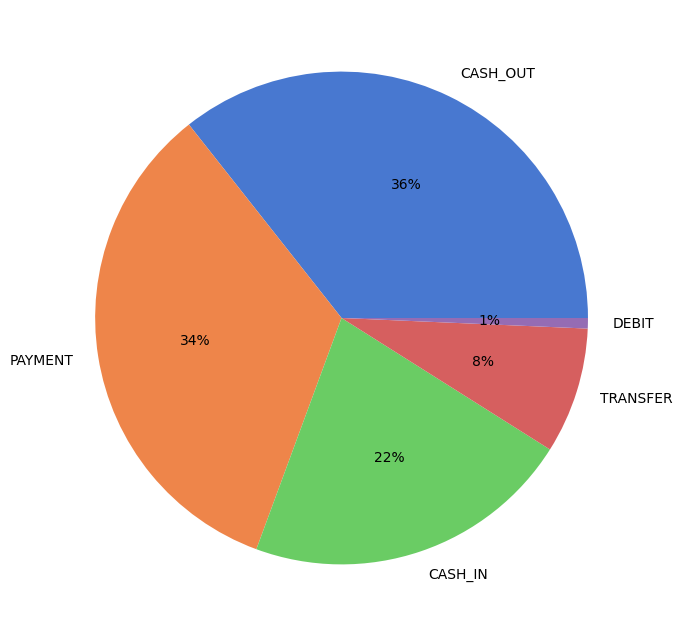

In [ ]:
display(Markdown('###**Круговая диаграмма количества совершенных операций по типам транзакций**'))
# data['type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(df['type'].value_counts().values, labels=df['type'].value_counts().index, colors=sns.color_palette('muted'), autopct='%.0f%%')
plt.show()

##### **Разница между балансами**

In [ ]:
df[round(abs(df['newbalanceOrig'] - df['oldbalanceOrg']),2) != round(abs(df['amount']),2)]

,Date,nameOrig,amount,oldbalanceOrg,newbalanceOrig,City,type,Card Type,Exp Type,Gender,isFraud


> amount равен разнице между новым и старым балансом

In [6]:
# Преобразуем Date из str в datetime
df['Date'] = df['Date'].apply(lambda x: datetime.strptime(x, '%d-%b-%y'))
df['Date'] = pd.to_datetime(df['Date'], errors='coerce',  format='%d-%b-%y')

Text(0, 0.5, 'Количество')

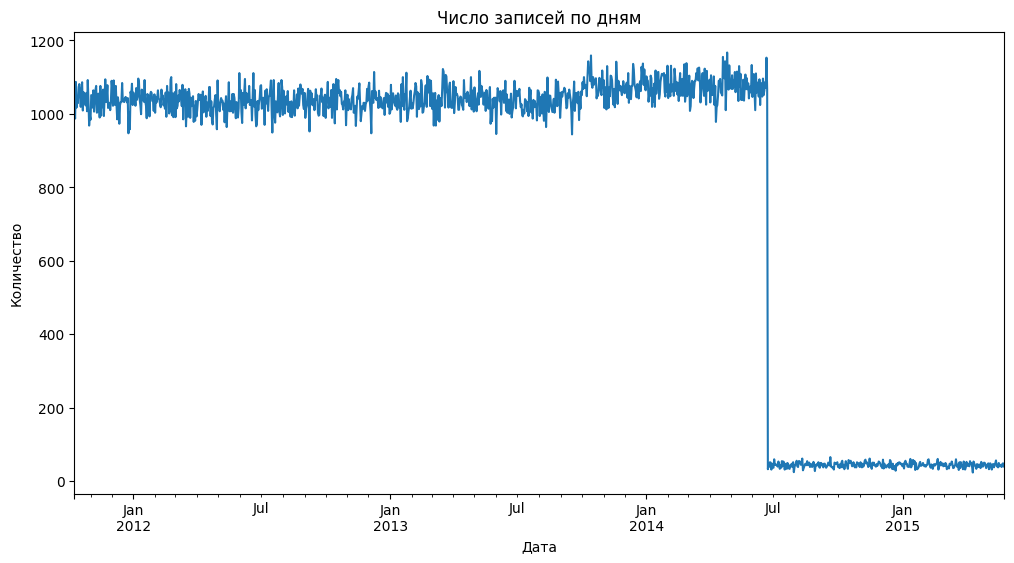

In [ ]:
daily_counts = (df
                .groupby(df['Date'])
                .size())

ax = daily_counts.plot(figsize=(12,6), title='Число записей по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество')

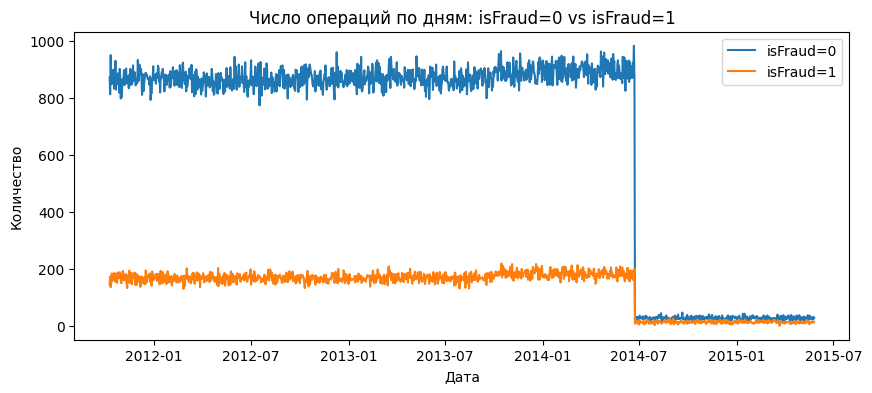

In [ ]:
# считаем число операций по дням и классу isFraud
daily_fraud = (
    df
    .assign(date=df['Date'].dt.date)
    .groupby(['date', 'isFraud'])
    .size()
    .unstack('isFraud', fill_value=0)
    .sort_index()
)

ax = daily_fraud.plot(figsize=(10,4), title='Число операций по дням: isFraud=0 vs isFraud=1')
ax.set_xlabel('Дата'); ax.set_ylabel('Количество')
ax.legend(['isFraud=0', 'isFraud=1'])

Резкое падение числа операций в июле 2014. Либо влияние какого-то события, либо особенность сборки датасета. Соотношение фродовых операций при этом сохранилось

In [7]:
df['City'].apply(lambda x: x.split(', ')[1]).unique()

array(['India'], dtype=object)

###**Круговая диаграмма распределения совершения транзакций по ТОП-10 городам**

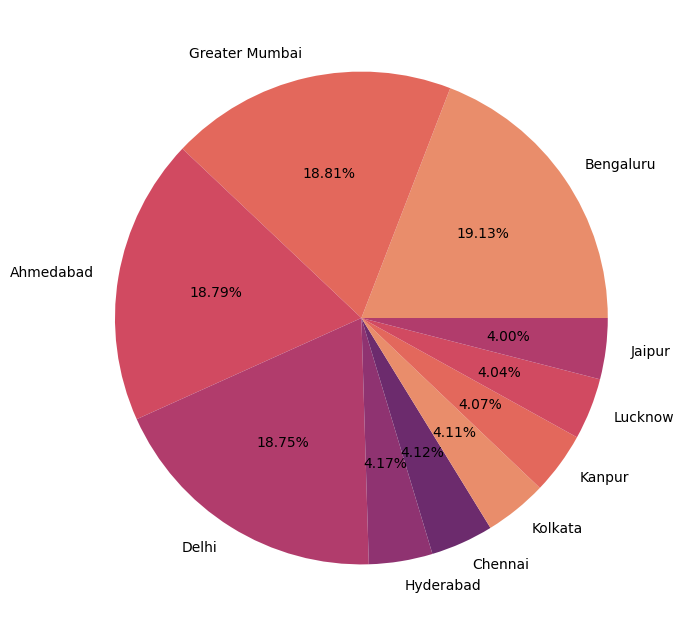

In [ ]:
display(Markdown('###**Круговая диаграмма распределения совершения транзакций по ТОП-10 городам**'))
top_transaction_cities = df['City'].apply(lambda x: x.split(', ')[0]).value_counts().head(10)
plt.figure(figsize=(8, 8))
plt.pie(top_transaction_cities.values, labels=top_transaction_cities.index, colors=sns.color_palette('flare'), autopct='%.2f%%')
plt.show()

> 4 крупнейших сегмента (вместе ~76%):

*   Бенгалуру
*   Дели
*   Ахмедабад
*   Мумбаи

> Остальные 6 городов (суммарно ~24%)
*   Хайдарабад
*   Ченнаи
*   Колката
*   Канпур
*   Лакхнау
*   Джайпур

In [8]:
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek

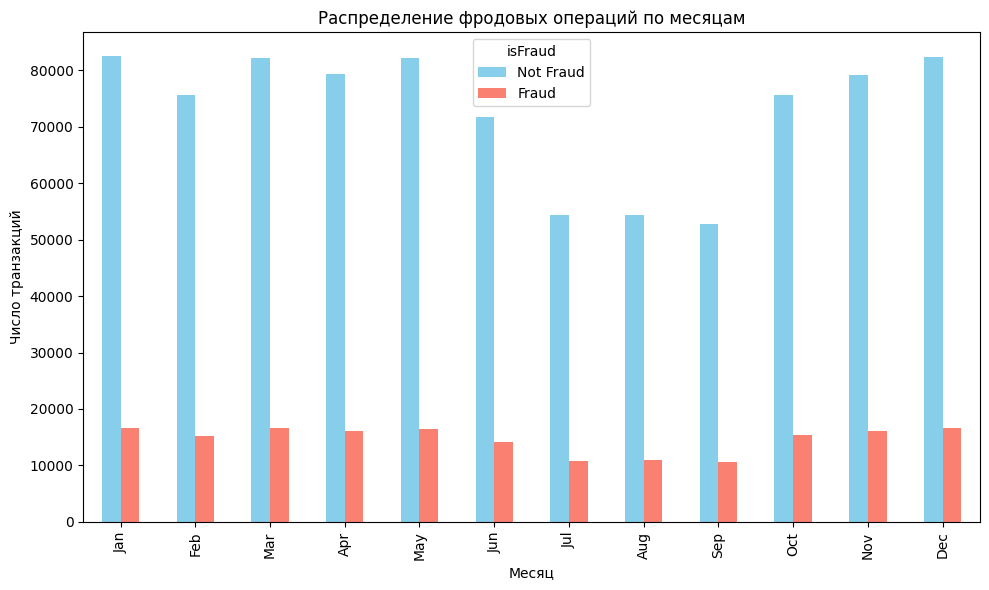

In [ ]:
fraud_by_month = df.groupby(['month', 'isFraud']).size().unstack(fill_value=0)
fraud_by_month.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Распределение фродовых операций по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Число транзакций')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='isFraud', labels=['Not Fraud', 'Fraud'])
plt.tight_layout()
plt.show()

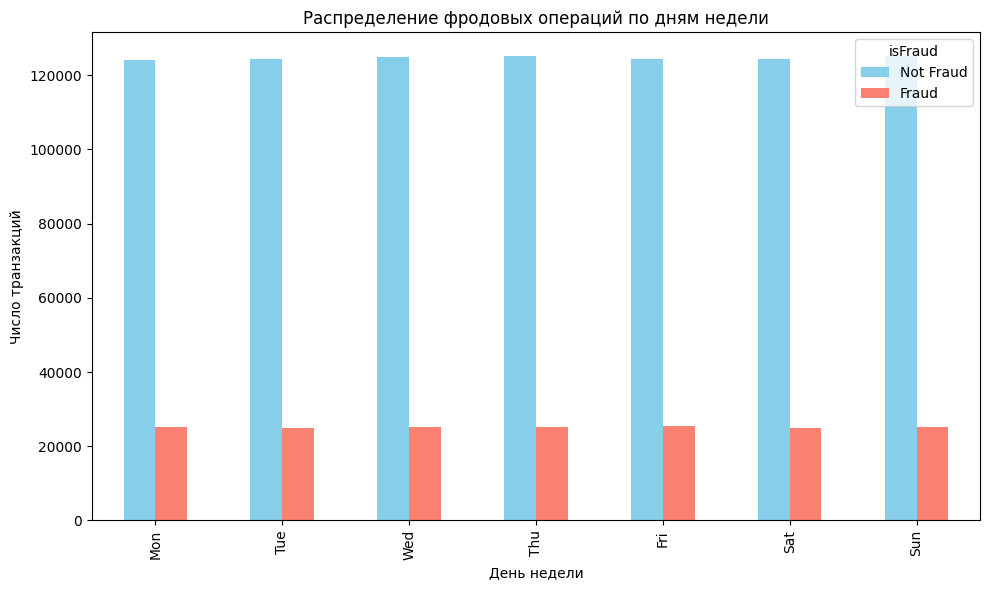

In [ ]:
fraud_by_dayofweek = df.groupby(['day_of_week', 'isFraud']).size().unstack(fill_value=0)
fraud_by_dayofweek.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Распределение фродовых операций по дням недели')
plt.xlabel('День недели')
plt.ylabel('Число транзакций')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.legend(title='isFraud', labels=['Not Fraud', 'Fraud'])
plt.tight_layout()
plt.show()


> Распределение фродовых операций внутри года и внутри недели равномерное

**Пока из модели удалим "Date", "nameOrig", "month" и "day_of_week":**

In [9]:
df_new = df.copy()
df_new = df_new.drop(['Date','nameOrig', 'month', 'day_of_week'],axis=1)
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   amount          1048574 non-null  float64
 1   oldbalanceOrg   1048574 non-null  float64
 2   newbalanceOrig  1048574 non-null  float64
 3   City            1048574 non-null  object 
 4   type            1048574 non-null  object 
 5   Card Type       1048574 non-null  object 
 6   Exp Type        1048574 non-null  object 
 7   Gender          1048574 non-null  object 
 8   isFraud         1048574 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 72.0+ MB


**Сделаем one-hot encoding для всех признаков, кроме "City"**

In [10]:
df_new_encoded = pd.get_dummies(df_new, columns=['type','Card Type', 'Exp Type', 'Gender'], drop_first=True)
df_new_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 23 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   amount                   1048574 non-null  float64
 1   oldbalanceOrg            1048574 non-null  float64
 2   newbalanceOrig           1048574 non-null  float64
 3   City                     1048574 non-null  object 
 4   isFraud                  1048574 non-null  int64  
 5   type_CASH_OUT            1048574 non-null  bool   
 6   type_DEBIT               1048574 non-null  bool   
 7   type_PAYMENT             1048574 non-null  bool   
 8   type_TRANSFER            1048574 non-null  bool   
 9   Card Type_Gold           1048574 non-null  bool   
 10  Card Type_Mass           1048574 non-null  bool   
 11  Card Type_Platinum       1048574 non-null  bool   
 12  Card Type_Signature      1048574 non-null  bool   
 13  Card Type_Silver         1048574 non-null 

**Разделим датасет на трейн и тест 70\30**

In [11]:
X = df_new_encoded.drop('isFraud', axis=1)
y = df_new_encoded['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

**Стандартизируем вещественные признаки:**

In [12]:
scaler = StandardScaler()

X_train[['amount','oldbalanceOrg','newbalanceOrig']] = scaler.fit_transform(X_train[['amount','oldbalanceOrg','newbalanceOrig']])
X_test[['amount','oldbalanceOrg','newbalanceOrig']] = scaler.transform(X_test[['amount','oldbalanceOrg','newbalanceOrig']])

**Далее 'City' перекодируем с помощью target encoding**

In [13]:
# кодирование целевой переменной
FEATURE = 'City'
TARGET = 'isFraud'
# параметры сглаживания
MIN_SAMPLES_LEAF = 50
SMOOTHING = 20

# вычисление глобального среднего целевой переменной
global_mean = y_train.mean()
print(f"Глобальное среднее мошенничества (для сглаживания): {global_mean:.4f}")

# расчёт и применение Target Encoding
temp_df = X_train[[FEATURE]].copy()
temp_df[TARGET] = y_train

agg = temp_df.groupby(FEATURE)[TARGET].agg(['count', 'mean'])
agg.columns = ['counts', 'mean_target']

# применение сглаживания
agg['lambda'] = 1 / (1 + np.exp((MIN_SAMPLES_LEAF - agg['counts']) / SMOOTHING))

# расчет сглаженного целевого значения
agg['smoothed_target'] = agg['lambda'] * agg['mean_target'] + (1 - agg['lambda']) * global_mean

# создание карты кодирования
city_encoding_map = agg['smoothed_target'].to_dict()

# применение кодирования к обучающему набору
X_train[f'{FEATURE}_TargetEncoded'] = X_train[FEATURE].map(city_encoding_map).fillna(global_mean)

# применение кодирования к тестовому набору
X_test[f'{FEATURE}_TargetEncoded'] = X_test[FEATURE].map(city_encoding_map)

# обработка непредставленных категорий в тесте
X_test[f'{FEATURE}_TargetEncoded'] = X_test[f'{FEATURE}_TargetEncoded'].fillna(global_mean)


# удаление исходного категориального признака
X_train = X_train.drop(FEATURE, axis=1)
X_test = X_test.drop(FEATURE, axis=1)

print("\nTarget Encoding завершен.")
print(f"Первые 5 значений нового признака в X_train: \n{X_train[f'{FEATURE}_TargetEncoded'].head()}")

Глобальное среднее мошенничества (для сглаживания): 0.1676

Target Encoding завершен.
Первые 5 значений нового признака в X_train: 
230565    0.171145
982532    0.169802
723425    0.169234
660727    0.170948
736648    0.171145
Name: City_TargetEncoded, dtype: float64


**Финальные фичи в трейне и тесте:**

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734001 entries, 230565 to 293268
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amount                   734001 non-null  float64
 1   oldbalanceOrg            734001 non-null  float64
 2   newbalanceOrig           734001 non-null  float64
 3   type_CASH_OUT            734001 non-null  bool   
 4   type_DEBIT               734001 non-null  bool   
 5   type_PAYMENT             734001 non-null  bool   
 6   type_TRANSFER            734001 non-null  bool   
 7   Card Type_Gold           734001 non-null  bool   
 8   Card Type_Mass           734001 non-null  bool   
 9   Card Type_Platinum       734001 non-null  bool   
 10  Card Type_Signature      734001 non-null  bool   
 11  Card Type_Silver         734001 non-null  bool   
 12  Exp Type_Entertainment   734001 non-null  bool   
 13  Exp Type_Food            734001 non-null  bool   
 14  Exp 

---


#### **Обучение**

**Обучаем логистическую регрессию:**

In [ ]:
log_reg_model = LogisticRegression(solver='saga', max_iter=2000, random_state=42)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42, solver='saga')

In [ ]:
y_pred = log_reg_model.predict(X_test)

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[253780   8057]
 [ 35283  17453]]

Отчет по классификации
              precision    recall  f1-score   support

           0       0.88      0.97      0.92    261837
           1       0.68      0.33      0.45     52736

    accuracy                           0.86    314573
   macro avg       0.78      0.65      0.68    314573
weighted avg       0.85      0.86      0.84    314573



***Модель №1***

Полнота (recall): Модель смогла обнаружить 33% действительно фродовых операций - Это очень мало

Прецизионность (precision): Из всех транзакций, которые модель пометила как фрод, 68% действительно им являются. Т.е. модель довольно много нефродовых операций считает фродовыми


Теперь будем балансировать классы:

In [ ]:
log_reg_balanced = LogisticRegression(
    class_weight='balanced',
    penalty='l2',
    solver='saga',
    max_iter=2000,
    random_state=42)

log_reg_balanced.fit(X_train, y_train)
y_pred_balanced = log_reg_balanced.predict(X_test)

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_balanced)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred_balanced))


Матрица Ошибок
[[156201 105636]
 [  3620  49116]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.60      0.74    261837
           1       0.32      0.93      0.47     52736

    accuracy                           0.65    314573
   macro avg       0.65      0.76      0.61    314573
weighted avg       0.87      0.65      0.70    314573



***Модель №2***

Полнота (recall): Модель смогла обнаружить 93% действительно фродовых операций - Это хорошо

Прецизионность (precision): Из всех транзакций, которые модель пометила как фрод, только 32% действительно им являются. Т.е. мы очень много нефродовых операций считаем фродом

In [ ]:
coefficients = log_reg_balanced.coef_[0]
feature_names = X_train.columns
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients})

print("Все Признаки")
print(feature_importance.to_string(index=False))

Все Признаки
                Признак  Коэффициент
                 amount    -0.058683
          oldbalanceOrg    -0.933963
         newbalanceOrig    -0.942472
          type_CASH_OUT     0.439283
             type_DEBIT    -1.560971
           type_PAYMENT    -2.694158
          type_TRANSFER     2.333943
         Card Type_Gold    -0.104330
         Card Type_Mass    -0.507270
     Card Type_Platinum    -0.114440
    Card Type_Signature    -0.103667
       Card Type_Silver    -0.083901
 Exp Type_Entertainment    -0.007681
          Exp Type_Food     0.017201
          Exp Type_Fuel     0.025948
       Exp Type_Grocery    -0.006847
Exp Type_Health_Fitness    -0.099647
          Exp Type_Home    -0.635822
 Exp Type_Personal_Care     0.106375
        Exp Type_Travel    -0.067597
               Gender_M    -0.005426
     City_TargetEncoded     7.523539


Город с исторически высоким уровнем мошенничества значительно повышает шансы на то что операция - фрод

TRANSFER - тоже сильный маркер, что операция фрод

***Теперь постороим дерево CART*** (без балансировки классов)

In [ ]:
# Создаём модель CART (DecisionTreeClassifier в sklearn = CART)
clf = DecisionTreeClassifier(
    criterion='gini',               # можно 'entropy', но Gini — стандарт CART
    max_depth=5,                    # ограничиваем глубину
    min_samples_split=20,           # минимум 20 объектов для разбиения
    min_samples_leaf=10,            # минимум 10 в листе
    random_state=42)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255628   6209]
 [ 35265  17471]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.33      0.46     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.86      0.87      0.85    314573



***Модель №3***

Все еще плохо - модель старается повысить точность за счет бОльшего по объему класса

***Теперь постороим дерево CART*** (с балансировкой классов)

In [20]:
clf = DecisionTreeClassifier(
    criterion='gini',               # можно 'entropy', но Gini — стандарт CART
    max_depth=15,                    # ограничиваем глубину
    min_samples_split=20,           # минимум 20 объектов для разбиения
    min_samples_leaf=10,            # минимум 10 в листе
    class_weight='balanced',
    random_state=42)

clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[186190  75647]
 [  4315  48421]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.71      0.82    261837
           1       0.39      0.92      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.68      0.81      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Модель №4***

Балансировка классов и увеличение глубины дерева сдвинули фокус модели с 0-го класса, тем самым предсказывая большинство фродовых операций, но снова в ущерб ложным срабатываниям на легальных транзакциях

**Следующий шаг - RANDOM FOREST**

In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, random_state=42)

In [ ]:
y_pred = model_rf.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255838   5999]
 [ 35604  17132]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.32      0.45     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.85      0.87      0.85    314573



***Модель №5***

В рандомном лесе опять выбор между recall и precision

***Модель №6***

Теперь попоробуем, как справится CatBoost, сначала без балансировки классов

In [ ]:
model_cb = CatBoostClassifier(random_state=42)
model_cb.fit(X_train, y_train)

Learning rate set to 0.17242
0:	learn: 0.5193902	total: 527ms	remaining: 8m 46s
1:	learn: 0.4255028	total: 832ms	remaining: 6m 55s
2:	learn: 0.3695486	total: 1.28s	remaining: 7m 4s
3:	learn: 0.3415390	total: 1.69s	remaining: 7m
4:	learn: 0.3236359	total: 2.1s	remaining: 6m 58s
5:	learn: 0.3113121	total: 2.65s	remaining: 7m 18s
6:	learn: 0.3060473	total: 3.16s	remaining: 7m 28s
7:	learn: 0.3030348	total: 3.66s	remaining: 7m 34s
8:	learn: 0.3004461	total: 4.12s	remaining: 7m 33s
9:	learn: 0.2976700	total: 4.64s	remaining: 7m 39s
10:	learn: 0.2958702	total: 5.16s	remaining: 7m 43s
11:	learn: 0.2951399	total: 5.69s	remaining: 7m 48s
12:	learn: 0.2936953	total: 6.21s	remaining: 7m 51s
13:	learn: 0.2930619	total: 6.74s	remaining: 7m 55s
14:	learn: 0.2926568	total: 7.12s	remaining: 7m 47s
15:	learn: 0.2924744	total: 7.42s	remaining: 7m 36s
16:	learn: 0.2920310	total: 7.69s	remaining: 7m 24s
17:	learn: 0.2916986	total: 8.01s	remaining: 7m 17s
18:	learn: 0.2914873	total: 8.31s	remaining: 7m 9s


CatBoostClassifier(random_state=42)

In [ ]:
y_pred = model_cb.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255625   6212]
 [ 35357  17379]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.33      0.46     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.85      0.87      0.85    314573



***Модель №6***

CatBoost не отличается от предыдущих попыток в лучшую сторону

***Модель №7***

Теперь попоробуем, как справится CatBoost с балансировкой классов

In [ ]:
model_cb = CatBoostClassifier(random_state=42, auto_class_weights='Balanced')
model_cb.fit(X_train, y_train)

Learning rate set to 0.17242
0:	learn: 0.5878860	total: 356ms	remaining: 5m 55s
1:	learn: 0.5225539	total: 642ms	remaining: 5m 20s
2:	learn: 0.4792878	total: 925ms	remaining: 5m 7s
3:	learn: 0.4555400	total: 1.2s	remaining: 4m 59s
4:	learn: 0.4387168	total: 1.49s	remaining: 4m 56s
5:	learn: 0.4286216	total: 1.79s	remaining: 4m 56s
6:	learn: 0.4219979	total: 2.11s	remaining: 4m 59s
7:	learn: 0.4182915	total: 2.34s	remaining: 4m 50s
8:	learn: 0.4147257	total: 2.68s	remaining: 4m 55s
9:	learn: 0.4127016	total: 3.08s	remaining: 5m 4s
10:	learn: 0.4110573	total: 3.57s	remaining: 5m 21s
11:	learn: 0.4091777	total: 4.04s	remaining: 5m 32s
12:	learn: 0.4081841	total: 4.59s	remaining: 5m 48s
13:	learn: 0.4075112	total: 5.16s	remaining: 6m 3s
14:	learn: 0.4068483	total: 5.63s	remaining: 6m 9s
15:	learn: 0.4063997	total: 6.1s	remaining: 6m 15s
16:	learn: 0.4056597	total: 6.68s	remaining: 6m 26s
17:	learn: 0.4054057	total: 7.36s	remaining: 6m 41s
18:	learn: 0.4050619	total: 7.9s	remaining: 6m 47s


CatBoostClassifier(auto_class_weights='Balanced', random_state=42)

In [ ]:
y_pred = model_cb.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[187647  74190]
 [  4370  48366]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.72      0.83    261837
           1       0.39      0.92      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Модель №7***

CatBoost с балансировкой классов показывает такой же результат, как и аналогичные деревянные модели

***Модель №8***

Теперь попробуем доверить предобработку признаков встроенным алгоритмам CatBoost, переопределим заново трейн и тест, сразу зададим балансировку классов, т.к. она всегда давала гораздо лучшие результаты

In [ ]:
X_orig = df_new.drop('isFraud', axis=1)
y_orig = df_new['isFraud']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig,
    test_size=0.3,
    random_state=42,
    stratify=y_orig)

In [ ]:
model_cb = CatBoostClassifier(random_state=42, auto_class_weights='Balanced', cat_features=['City',	'type',	'Card Type',	'Exp Type',	'Gender'])
model_cb.fit(X_train_orig, y_train_orig)

Learning rate set to 0.17242
0:	learn: 0.5875636	total: 1.55s	remaining: 25m 46s
1:	learn: 0.5236401	total: 3.21s	remaining: 26m 39s
2:	learn: 0.4833974	total: 5.51s	remaining: 30m 32s
3:	learn: 0.4576940	total: 7.95s	remaining: 33m
4:	learn: 0.4417001	total: 10.4s	remaining: 34m 30s
5:	learn: 0.4330971	total: 12.3s	remaining: 33m 50s
6:	learn: 0.4255750	total: 14s	remaining: 33m 2s
7:	learn: 0.4203879	total: 15.6s	remaining: 32m 17s
8:	learn: 0.4173286	total: 17.3s	remaining: 31m 46s
9:	learn: 0.4133883	total: 18.5s	remaining: 30m 28s
10:	learn: 0.4105615	total: 19.4s	remaining: 29m
11:	learn: 0.4087658	total: 20.6s	remaining: 28m 15s
12:	learn: 0.4076273	total: 22.2s	remaining: 28m 2s
13:	learn: 0.4070707	total: 23.6s	remaining: 27m 41s
14:	learn: 0.4063061	total: 25.4s	remaining: 27m 47s
15:	learn: 0.4059890	total: 26.6s	remaining: 27m 14s
16:	learn: 0.4052703	total: 27.5s	remaining: 26m 28s
17:	learn: 0.4050206	total: 28.4s	remaining: 25m 47s
18:	learn: 0.4045442	total: 30.2s	remai

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['City', 'type', 'Card Type', 'Exp Type', 'Gender'], random_state=42)

In [ ]:
y_pred = model_cb.predict(X_test_orig)

conf_matrix = confusion_matrix(y_test_orig, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test_orig, y_pred))


Матрица Ошибок
[[186794  75043]
 [  3981  48755]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.71      0.83    261837
           1       0.39      0.92      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



И снова чуда не произошло (((

In [14]:
def objective_dt(trial):
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)

    score = cross_val_score(DecisionTreeClassifier(
                                                    criterion='gini',
                                                    max_depth=max_depth,
                                                    min_samples_split=min_samples_split,
                                                    min_samples_leaf=min_samples_leaf,
                                                    class_weight='balanced',
                                                    random_state=42),
                            X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()
    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective_dt, n_trials=50)

[I 2026-03-10 18:58:53,883] A new study created in memory with name: no-name-997214b7-867e-43c5-9ffb-4f980289a395
[I 2026-03-10 18:59:21,496] Trial 0 finished with value: 0.544620286385905 and parameters: {'max_depth': 18, 'min_samples_leaf': 1, 'min_samples_split': 12}. Best is trial 0 with value: 0.544620286385905.
[I 2026-03-10 18:59:44,972] Trial 1 finished with value: 0.5421155261408378 and parameters: {'max_depth': 18, 'min_samples_leaf': 4, 'min_samples_split': 10}. Best is trial 0 with value: 0.544620286385905.
[I 2026-03-10 18:59:52,608] Trial 2 finished with value: 0.552826175483966 and parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 7}. Best is trial 2 with value: 0.552826175483966.
[I 2026-03-10 19:00:15,718] Trial 3 finished with value: 0.548171665156466 and parameters: {'max_depth': 14, 'min_samples_leaf': 4, 'min_samples_split': 12}. Best is trial 2 with value: 0.552826175483966.
[I 2026-03-10 19:00:37,971] Trial 4 finished with value: 0.54265546

In [15]:
study.best_params

{'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5}

In [16]:
model = DecisionTreeClassifier(**study.best_params, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [17]:
y_pred = model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[184491  77346]
 [  3552  49184]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.70      0.82    261837
           1       0.39      0.93      0.55     52736

    accuracy                           0.74    314573
   macro avg       0.68      0.82      0.68    314573
weighted avg       0.88      0.74      0.77    314573



***Подбор гиперпараметров***

На модели № 4, которая оказалась с лучшими метриками при высокой скорости обучения, подбор гиперпараметров не дал прироста качества. Постараемся из нее же получить прирост за счет работы с признаками

In [23]:
from sklearn.preprocessing import PolynomialFeatures


numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'City_TargetEncoded']

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_num = X_train[numerical_features]
X_train_bool = X_train.drop(columns=numerical_features)

X_train_poly = poly.fit_transform(X_train_num)
poly_feature_names = poly.get_feature_names_out(numerical_features)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)
X_train_extended = pd.concat([X_train_poly_df, X_train_bool], axis=1)


X_test_num = X_test[numerical_features]
X_test_bool = X_test.drop(columns=numerical_features)
X_test_poly = poly.transform(X_test_num)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_feature_names, index=X_test.index)
X_test_extended = pd.concat([X_test_poly_df, X_test_bool], axis=1)

print("Размерность X_train_extended:", X_train_extended.shape)
print("Размерность of X_test_extended:", X_test_extended.shape)


model_poly = DecisionTreeClassifier(**study.best_params, class_weight='balanced', random_state=42)
model_poly.fit(X_train_extended, y_train)
y_pred_poly = model_poly.predict(X_test_extended)

print("\nМатрица Ошибок с полиномиальными признаками")
print(confusion_matrix(y_test, y_pred_poly))

print("\nОтчет по Классификации с полиномиальными признаками")
print(classification_report(y_test, y_pred_poly))

Размерность X_train_extended: (734001, 32)
Размерность of X_test_extended: (314573, 32)

Матрица Ошибок с полиномиальными признаками
[[186732  75105]
 [  3942  48794]]

Отчет по Классификации с полиномиальными признаками
              precision    recall  f1-score   support

           0       0.98      0.71      0.83    261837
           1       0.39      0.93      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Добавление полиномиальных признаков степени 2***

Получили незначительный, но всё же 1% на `recall` для класса 0.

In [27]:
model_poly.feature_importances_

array([2.06070140e-03, 1.25038158e-01, 7.77329501e-03, 4.52657301e-04,
       5.53064771e-05, 2.91031540e-04, 1.91786785e-03, 2.19618964e-04,
       6.16272715e-03, 3.07520555e-01, 1.43692855e-03, 4.89912193e-03,
       1.05819435e-03, 4.11414710e-03, 5.95073597e-04, 5.55188939e-03,
       4.26921298e-01, 1.03527734e-01, 1.53803304e-05, 0.00000000e+00,
       6.03512204e-05, 0.00000000e+00, 2.30516319e-05, 2.75214021e-05,
       4.42670692e-05, 7.28911361e-05, 4.42024738e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 6.66900257e-06, 1.09359442e-04])

In [31]:
feature_names = X_train_extended.columns
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': model_poly.feature_importances_})

print("Все Признаки")
print(feature_importance.sort_values(by='Коэффициент', ascending=False, ).to_string(index=False))

Все Признаки
                          Признак  Коэффициент
                     type_PAYMENT     0.426921
     oldbalanceOrg newbalanceOrig     0.307521
                    oldbalanceOrg     0.125038
                    type_TRANSFER     0.103528
                   newbalanceOrig     0.007773
                  oldbalanceOrg^2     0.006163
                       type_DEBIT     0.005552
                 newbalanceOrig^2     0.004899
             City_TargetEncoded^2     0.004114
                           amount     0.002061
            amount newbalanceOrig     0.001918
 oldbalanceOrg City_TargetEncoded     0.001437
newbalanceOrig City_TargetEncoded     0.001058
                    type_CASH_OUT     0.000595
               City_TargetEncoded     0.000453
             amount oldbalanceOrg     0.000291
        amount City_TargetEncoded     0.000220
                         Gender_M     0.000109
                    Exp Type_Fuel     0.000073
               Card Type_Platinum     0.000060


In [40]:
model_drop = DecisionTreeClassifier(**study.best_params, class_weight='balanced', random_state=42)
model_drop.fit(X_train_extended.drop(['Exp Type_Fuel', 'Card Type_Platinum', 'amount^2', 'Exp Type_Food', 'Exp Type_Grocery', 'Exp Type_Entertainment', 'Card Type_Silver', 'Card Type_Gold', 'Exp Type_Travel', 'Card Type_Mass', 'Card Type_Signature', 'Exp Type_Health_Fitness', 'Exp Type_Personal_Care', 'Exp Type_Home'], axis=1), y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [41]:
y_pred = model_drop.predict(X_test_extended.drop(['Exp Type_Fuel', 'Card Type_Platinum', 'amount^2', 'Exp Type_Food', 'Exp Type_Grocery', 'Exp Type_Entertainment', 'Card Type_Silver', 'Card Type_Gold', 'Exp Type_Travel', 'Card Type_Mass', 'Card Type_Signature', 'Exp Type_Health_Fitness', 'Exp Type_Personal_Care', 'Exp Type_Home'], axis=1))

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[186729  75108]
 [  3941  48795]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.71      0.83    261837
           1       0.39      0.93      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Удаление незначимых признаков***

После удаления почти половины признаков метрики не изменились